## Load NSE Data into PostgreSQL
This notebook reads all 19 annual NSE CSV files, cleans them and writes them to the database.
Prerequisites:
pip install -r requirements.txt
docker-compose up -d
docker exec -i ...
all csv files in raw

In [118]:
import os, sys, logging
import numpy as np
import pandas as pd
from sqlalchemy import create_engine, text
from pathlib import Path
from dotenv import load_dotenv

load_dotenv()
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)-8s %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger(__name__)

DB_URL = (
    f"postgresql://{os.getenv('DB_USER','postgres')}:"
    f"{os.getenv('DB_PASSWORD','nse_password')}@"
    f"{os.getenv('DB_HOST','localhost')}:"
    f"{os.getenv('DB_PORT','5432')}/"
    f"{os.getenv('DB_NAME','nse_portfolio')}"
)
RAW = Path("raw")
print("Imports OK")

Imports OK


## Define the stock environment
67 qualifying equities sorted alphabetically

In [119]:
ALL_TICKERS = sorted([
    "ABSA","ARM","BAMB","BAT","BKG","BOC","BRIT","CABL","CARB","CGEN",
    "CIC","COOP","CRWN","CTUM","DCON","DTK","EABL","EGAD","EQTY","EVRD",
    "FAHR","FTGH","GLD","HAFR","HBE","HFCK","IMH","JUB","KAPC","KCB",
    "KEGN","KNRE","KPLC","KPLC-P4","KPLC-P7","KQ","KUKZ","KURV","LAPR",
    "LBTY","LIMT","LKL","MSC","NBK","NBV","NCBA","NMG","NSE","OCH",
    "ORCH","PORT","SASN","SBIC","SCAN","SCBK","SCOM","SGL","SLAM","SMER",
    "TCL","TOTL","TPSE","UCHM","UMME","UNGA","WTK","XPRS",
])
print(f"Stock universe: {len(ALL_TICKERS)} qualifying equities")

Stock universe: 67 qualifying equities


## Helper functions to normalise columns, parse dates

In [120]:
def normalise_cols(df):
    rn = {}
    for c in df.columns:
        cu = c.upper().strip()
        if   cu == "DATE":                              rn[c] = "date"
        elif cu == "CODE":                              rn[c] = "ticker"
        elif cu == "NAME":                              rn[c] = "name"
        elif cu == "12M LOW":                           rn[c] = "low_52w"
        elif cu == "12M HIGH":                          rn[c] = "high_52w"
        elif cu == "DAY LOW":                           rn[c] = "low"
        elif cu == "DAY HIGH":                          rn[c] = "high"
        elif cu == "DAY PRICE":                         rn[c] = "close"
        elif cu == "PREVIOUS":                          rn[c] = "prev_close"
        elif cu == "CHANGE":                            rn[c] = "change_val"
        elif cu in ("CHANGE%", "CHANGE %"):             rn[c] = "change_pct"
        elif cu == "VOLUME":                            rn[c] = "volume"
        elif cu in ("ADJUST", "ADJUSTED", "ADJUSTED PRICE"): rn[c] = "adj_close"
    return df.rename(columns=rn)

def parse_date(series, year):
    if year <= 2012:
        return pd.to_datetime(series, format="%m/%d/%Y", errors="coerce")
    parsed = pd.to_datetime(series, format="%d-%b-%y", errors="coerce")
    if parsed.isna().mean() > 0.05:
        parsed = pd.to_datetime(series, dayfirst=True, errors="coerce")
    return parsed

def to_num(series):
    return (
        series.astype(str)
        .str.replace(",", "", regex=False)
        .str.strip()
        .replace("-", np.nan)
        .replace("", np.nan)
        .pipe(pd.to_numeric, errors="coerce")
    )

print("Helper functions defined")

Helper functions defined


## Load all 19 CSV files

In [121]:
from pathlib import Path

RAW = Path("raw")

print("Working directory:", Path.cwd())
print("RAW resolves to:", RAW.resolve())
print()

# Check if the folder exists at all
print("Folder exists:", RAW.exists())

# List everything in the raw folder
if RAW.exists():
    all_files = list(RAW.iterdir())
    print(f"Total files in raw/: {len(all_files)}")
    print()
    print("First 5 files:")
    for f in all_files[:5]:
        print(" ", f.name)
else:
    print("Folder does not exist")
    print()
    print("Contents of current directory:")
    for item in Path(".").iterdir():
        print(" ", item)

Working directory: c:\Users\Administrator\nse_portfolio_rl\data
RAW resolves to: C:\Users\Administrator\nse_portfolio_rl\data\raw

Folder exists: True
Total files in raw/: 20

First 5 files:
  .gitkeep
  NSE_data_all_stocks_2007.csv
  NSE_data_all_stocks_2008.csv
  NSE_data_all_stocks_2009.csv
  NSE_data_all_stocks_2010.csv


In [122]:
csv_files = sorted(RAW.glob("*.csv"))
print(f"Found {len(csv_files)} CSV files")

frames = []
for path in csv_files:
    year = int(path.stem.split("_")[-1])
    df   = pd.read_csv(path, encoding="utf-8-sig", low_memory=False)
    df.columns = df.columns.str.strip()
    df   = normalise_cols(df)
    df["date"]   = parse_date(df["date"], year)
    df["ticker"] = df["ticker"].astype(str).str.strip().str.upper()
    frames.append(df)
    print(f"  {year}: {len(df):,} rows, {df['ticker'].nunique()} tickers")

raw = pd.concat(frames, ignore_index=True)
print(f"\nCombined: {len(raw):,} rows")

Found 19 CSV files
  2007: 10,608 rows, 55 tickers
  2008: 10,583 rows, 56 tickers
  2009: 14,386 rows, 59 tickers
  2010: 14,952 rows, 63 tickers
  2011: 14,931 rows, 61 tickers
  2012: 16,044 rows, 69 tickers
  2013: 14,889 rows, 62 tickers
  2014: 15,696 rows, 66 tickers
  2015: 16,386 rows, 67 tickers
  2016: 16,800 rows, 69 tickers
  2017: 16,981 rows, 70 tickers
  2018: 17,651 rows, 74 tickers
  2019: 18,147 rows, 73 tickers
  2020: 17,892 rows, 71 tickers
  2021: 17,746 rows, 71 tickers
  2022: 16,806 rows, 71 tickers
  2023: 17,274 rows, 72 tickers
  2024: 18,119 rows, 74 tickers
  2025: 15,114 rows, 75 tickers

Combined: 301,005 rows


## Filtering and Cleaning

In [123]:
df = raw[raw["ticker"].isin(ALL_TICKERS)].copy()
df = df.dropna(subset=["date"])

def to_num(series):
    return (
        series.astype(str)
        .str.replace(",", "", regex=False)   # "416,380,000" -> "416380000"
        .str.replace("%", "", regex=False)   # "0.32%"       -> "0.32"
        .str.strip()
        .replace("-", np.nan)
        .replace("", np.nan)
        .pipe(pd.to_numeric, errors="coerce")
    )

for col in ["close","high","low","prev_close","volume","adj_close",
            "low_52w","high_52w","change_val","change_pct"]:
    if col in df.columns:
        df[col] = to_num(df[col])
# Fix volume: convert float to integer, cap at BIGINT max, set negatives to null
BIGINT_MAX = 9_223_372_036_854_775_807
df["volume"] = df["volume"].clip(upper=BIGINT_MAX)
df["volume"] = df["volume"].where(df["volume"] >= 0, np.nan)
df["volume"] = df["volume"].apply(lambda x: int(x) if pd.notna(x) else None)

# Fall back to raw close when adj_close is missing
missing = df["adj_close"].isna().sum()
df["adj_close"] = df["adj_close"].fillna(df["close"])
print(f"Filled {missing:,} missing adj_close values with raw close")

df = df[df["close"] > 0].copy()
df = df.drop_duplicates(subset=["date", "ticker"], keep="last")
df = df.sort_values(["ticker", "date"]).reset_index(drop=True)
print(f"After cleaning: {len(df):,} rows, {df['ticker'].nunique()} tickers")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")

Filled 226,015 missing adj_close values with raw close
After cleaning: 256,611 rows, 67 tickers
Date range: 2007-01-02 to 2025-10-31


Forward filling for short gaps is chosen for this. This is a range of about 1-5 days. Gaps longer than 5 days remain unfilled and the environment treats those as days when the stock is unavailable

In [124]:
calendar = pd.date_range(df["date"].min(), df["date"].max(), freq="B")
num_cols  = ["close","high","low","adj_close","prev_close","volume","low_52w","high_52w"]
filled_frames = []

for ticker in ALL_TICKERS:
    sub = df[df["ticker"] == ticker].set_index("date").sort_index()
    if sub.empty:
        continue
    sub = sub.reindex(calendar)
    sub["ticker"] = ticker
    cols = [c for c in num_cols if c in sub.columns]
    sub[cols] = sub[cols].ffill(limit=5)
    sub = sub.dropna(subset=["close"])
    filled_frames.append(sub.reset_index().rename(columns={"index": "date"}))

filled = pd.concat(filled_frames, ignore_index=True)
print(f"After gap-fill: {len(filled):,} rows, {filled['ticker'].nunique()} tickers")

After gap-fill: 270,465 rows, 67 tickers


## Compute observation Features
For each stock on each trading day, the model uses seven features that are calculated exclusively from historical information, ensuring there is no lookahead bias. These features include **1-day log return** ((\log(p_t/p_{t-1}))), which captures short-term noise and reversal effects; **5-day log return** ((\log(p_t/p_{t-5}))), which measures weekly momentum; **20-day log return** ((\log(p_t/p_{t-20}))), representing monthly momentum; and **60-day log return** ((\log(p_t/p_{t-60}))), which captures the longer-term quarterly trend. The model also incorporates **20-day volatility**, calculated as the standard deviation of daily returns over the previous 20 trading days, to provide a measure of risk since higher volatility generally reduces risk-adjusted performance as measured by the Sharpe ratio. To account for market frictions, two liquidity indicators are included: the **Corwin–Schultz bid-ask spread estimator** (Corwin & Schultz, 2012), which proxies transaction costs and liquidity constraints, and the **Amihud illiquidity measure** (Amihud, 2002), which captures price impact and trading difficulty. Among these features, the **60-day return is particularly important** because it helps the agent determine whether a trend is strong enough to overcome the approximately 4.16% round-trip transaction cost in the Nairobi Securities Exchange (NSE). For example, a stock generating an average return of 0.07% per day over 60 trading days produces a cumulative return of roughly 4.2%, just exceeding the transaction-cost breakeven point. Consequently, the 60-day return provides a crucial signal that helps the agent evaluate whether entering and holding a position is likely to generate sufficient profit after costs.


In [125]:
feature_frames = []

for i, ticker in enumerate(ALL_TICKERS):
    sub = filled[filled["ticker"] == ticker].sort_values("date").copy()
    if len(sub) < 65:
        continue
    p = sub["adj_close"]

    sub["return_1d"]  = np.log(p / p.shift(1))
    sub["return_5d"]  = np.log(p / p.shift(5))
    sub["return_20d"] = np.log(p / p.shift(20))
    sub["return_60d"] = np.log(p / p.shift(60))
    sub["vol_20d"]    = sub["return_1d"].rolling(20, min_periods=10).std()

    # Corwin-Schultz spread
    h  = sub["high"].replace(0, np.nan)
    l  = sub["low"].replace(0, np.nan)
    bt = np.log(h / l) ** 2
    bt1 = bt.shift(-1)
    h2 = h.rolling(2).max()
    l2 = l.rolling(2).min()
    gm = np.log(h2 / l2.replace(0, np.nan)) ** 2
    k  = 3 - 2 * np.sqrt(2)
    ba = (bt + bt1) / 2
    with np.errstate(invalid="ignore", divide="ignore"):
        al = (np.sqrt(2 * ba) - np.sqrt(ba)) / k - np.sqrt(gm / k)
        sp = 2 * (np.exp(al) - 1) / (1 + np.exp(al))
    sub["cs_spread"] = np.clip(np.nan_to_num(sp, nan=0.0), 0.0, 0.30)

    # Amihud illiquidity
    tv = sub["volume"] * p
    sub["amihud"] = (
        sub["return_1d"].abs() / tv.replace(0, np.nan)
    ).rolling(20, min_periods=10).mean()

    feature_frames.append(sub[[
        "date", "ticker",
        "return_1d", "return_5d", "return_20d", "return_60d",
        "vol_20d", "cs_spread", "amihud",
    ]])

    if (i + 1) % 15 == 0:
        print(f"  Features: {i+1}/{len(ALL_TICKERS)} stocks done")

features = pd.concat(feature_frames, ignore_index=True)
features  = features.replace([np.inf, -np.inf], np.nan)
print(f"Features computed: {len(features):,} rows")

  Features: 15/67 stocks done
  Features: 30/67 stocks done
  Features: 45/67 stocks done
  Features: 60/67 stocks done
Features computed: 270,465 rows


## Connect to DB

In [126]:
engine = create_engine(DB_URL, pool_pre_ping=True)
try:
    with engine.connect() as conn:
        conn.execute(text("SELECT 1"))
    print("Database connection OK")
except Exception as e:
    print(f"ERROR: {e}")
    print("Ensure Docker is running:  docker-compose up -d")
    raise

Database connection OK


## Write Prices to DB

In [127]:
with engine.begin() as conn:
    conn.execute(text("ALTER TABLE nse_prices ALTER COLUMN volume TYPE NUMERIC(20,0)"))
print("Volume column type updated")

Volume column type updated


In [128]:
def batch_write(df, engine, sql, batch_size=5000):
    rows = df.where(pd.notnull(df), None).to_dict(orient="records")
    total = len(rows)
    for i in range(0, total, batch_size):
        with engine.begin() as conn:
            conn.execute(text(sql), rows[i:i + batch_size])
        print(f"  {min(i + batch_size, total):,} / {total:,}", end="\r")
    print()

price_cols = ["date","ticker","name","high","low","close","adj_close",
              "volume","high_52w","low_52w","prev_close","change_val","change_pct"]
price_df   = filled[[c for c in price_cols if c in filled.columns]].copy()

print("Writing prices ...")
batch_write(price_df, engine, """
    INSERT INTO nse_prices
        (date,ticker,name,high,low,close,adj_close,volume,
         high_52w,low_52w,prev_close,change_val,change_pct)
    VALUES
        (:date,:ticker,:name,:high,:low,:close,:adj_close,:volume,
         :high_52w,:low_52w,:prev_close,:change_val,:change_pct)
    ON CONFLICT (date,ticker) DO UPDATE SET
        close=EXCLUDED.close, adj_close=EXCLUDED.adj_close,
        high=EXCLUDED.high, low=EXCLUDED.low, volume=EXCLUDED.volume
""")
print("Prices written.")

Writing prices ...
  270,465 / 270,465
Prices written.


## Write Features to DB

In [129]:
print("Writing features ...")
batch_write(features, engine, """
    INSERT INTO nse_features
        (date,ticker,return_1d,return_5d,return_20d,return_60d,
         vol_20d,cs_spread,amihud)
    VALUES
        (:date,:ticker,:return_1d,:return_5d,:return_20d,:return_60d,
         :vol_20d,:cs_spread,:amihud)
    ON CONFLICT (date,ticker) DO UPDATE SET
        return_60d=EXCLUDED.return_60d,
        cs_spread=EXCLUDED.cs_spread,
        amihud=EXCLUDED.amihud
""")
print("Features written.")

Writing features ...
  270,465 / 270,465
Features written.


In [130]:
##validation report

In [131]:
with engine.connect() as conn:
    rows = conn.execute(text(
        "SELECT ticker, COUNT(*) r, MIN(date) f, MAX(date) l "
        "FROM nse_prices GROUP BY ticker ORDER BY r DESC"
    )).fetchall()

print(f"{'Ticker':<12} {'Rows':>6}  {'First':>12}  {'Last':>12}")
print("-" * 48)
for r in rows:
    print(f"{r[0]:<12} {r[1]:>6,}  {str(r[2]):>12}  {str(r[3]):>12}")

with engine.connect() as conn:
    fc = conn.execute(text("SELECT COUNT(*) FROM nse_features")).scalar()

print(f"\nFeature rows: {fc:,}")
print(f"Tickers loaded: {len(rows)} / {len(ALL_TICKERS)}")
print("\nDatabase ready. Open training/02_train.ipynb next.")

Ticker         Rows         First          Last
------------------------------------------------
NMG           4,913    2007-01-02    2025-10-31
HFCK          4,913    2007-01-02    2025-10-31
BAMB          4,913    2007-01-02    2025-10-31
BAT           4,913    2007-01-02    2025-10-31
XPRS          4,913    2007-01-02    2025-10-31
KQ            4,913    2007-01-02    2025-10-31
UNGA          4,913    2007-01-02    2025-10-31
CABL          4,913    2007-01-02    2025-10-31
TPSE          4,913    2007-01-02    2025-10-31
TOTL          4,913    2007-01-02    2025-10-31
JUB           4,913    2007-01-02    2025-10-31
KPLC          4,913    2007-01-02    2025-10-31
KEGN          4,913    2007-01-02    2025-10-31
SCBK          4,913    2007-01-02    2025-10-31
SCAN          4,913    2007-01-02    2025-10-31
DTK           4,913    2007-01-02    2025-10-31
EABL          4,913    2007-01-02    2025-10-31
KCB           4,913    2007-01-02    2025-10-31
EQTY          4,913    2007-01-02    20

## Visualizations

FileNotFoundError: [Errno 2] No such file or directory: 'plots/data_engineering_summary.png'

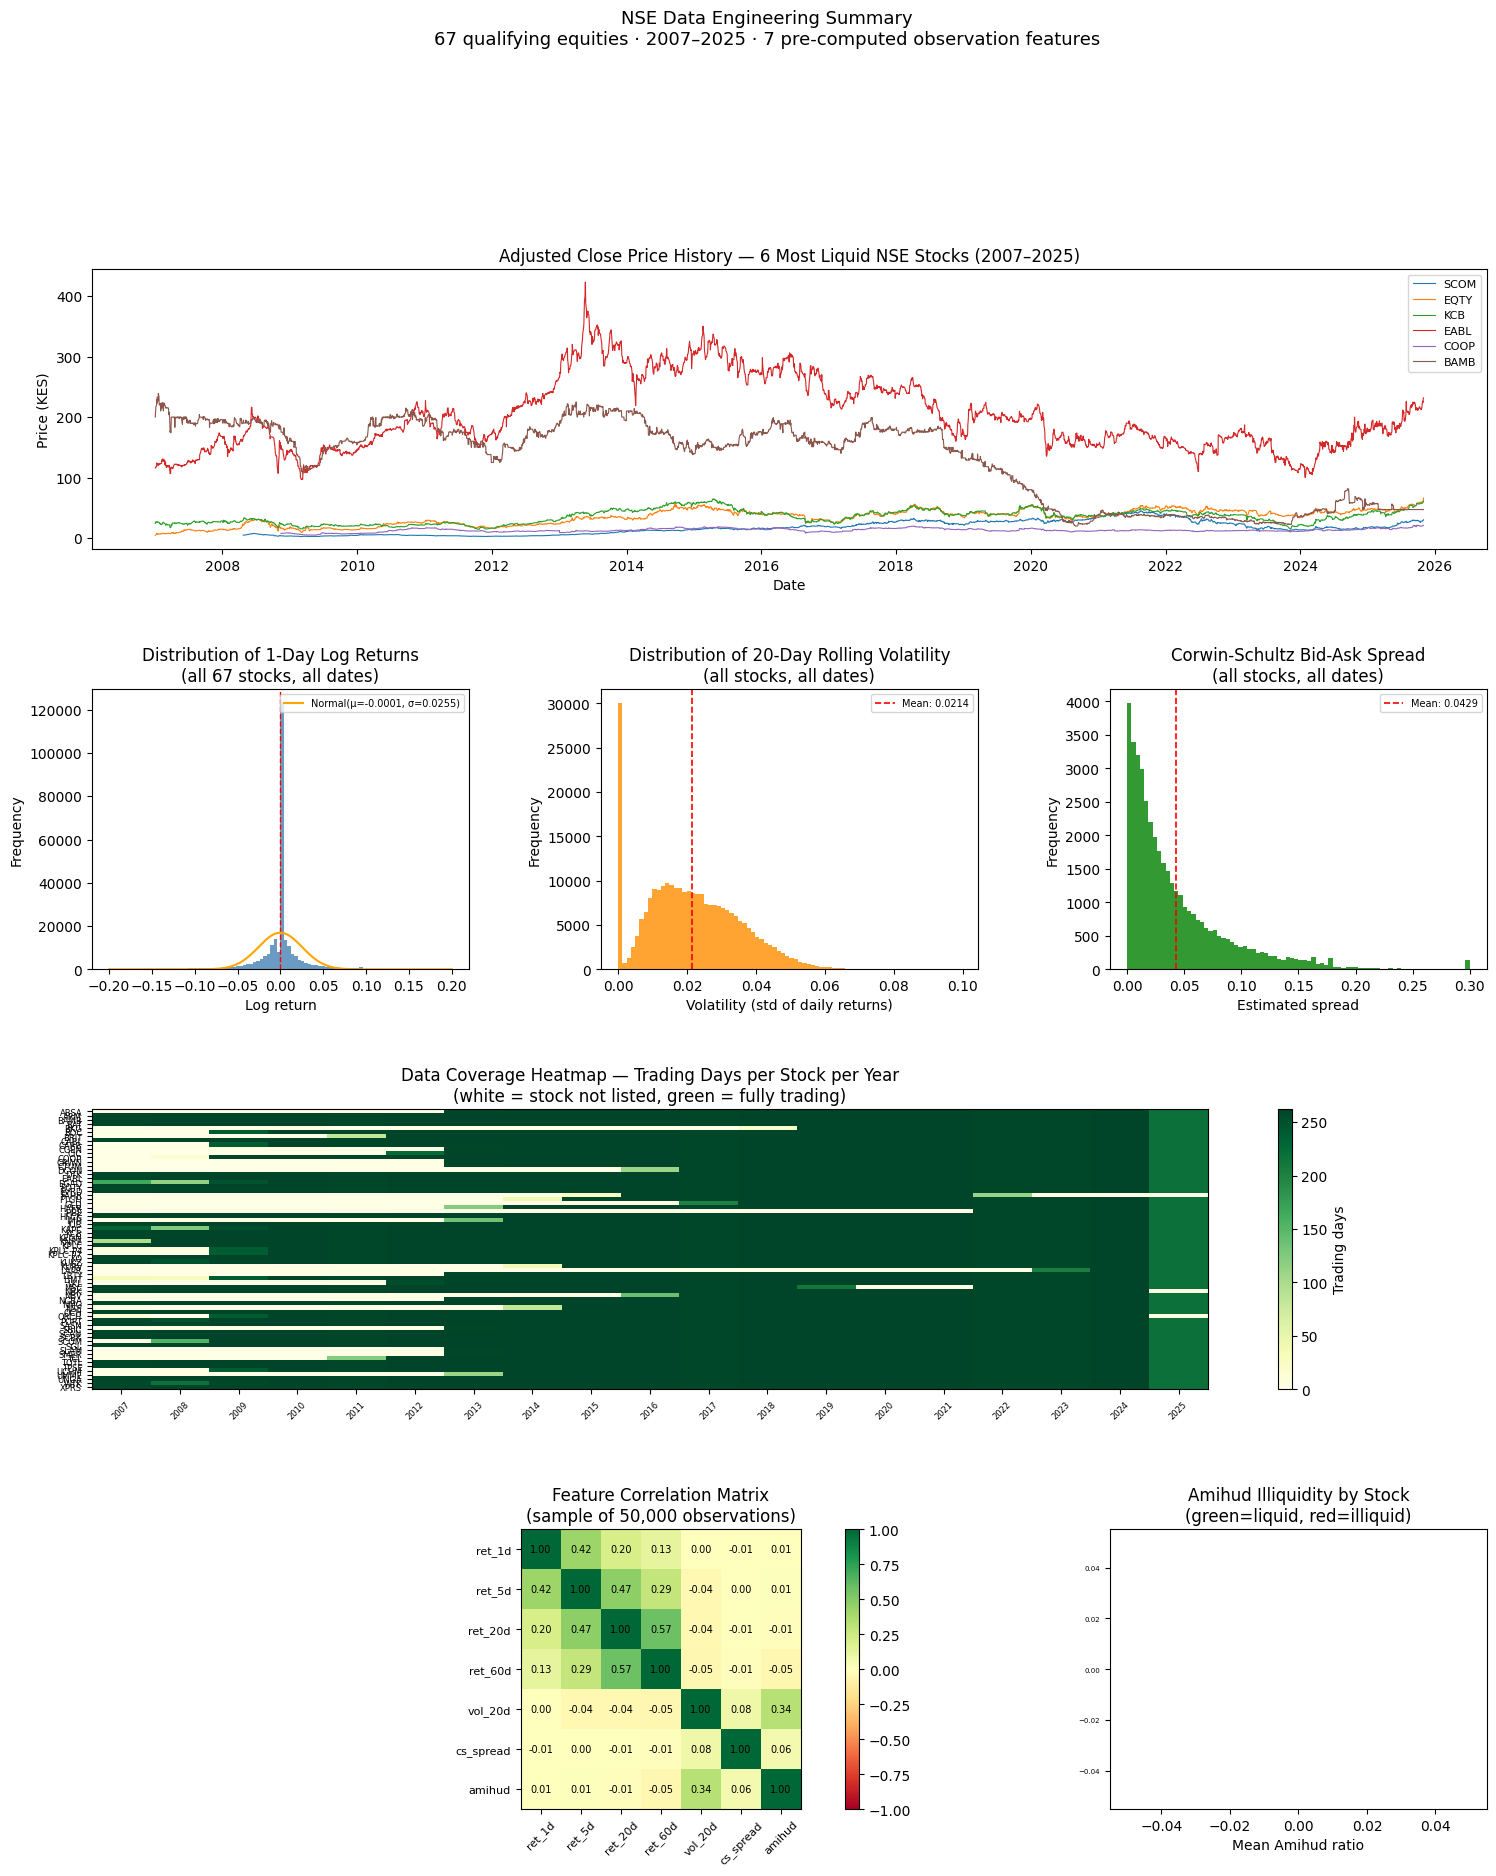

In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
from sqlalchemy import text
from scipy import stats

# Create plots folder if it doesn't exist
os.makedirs("plots", exist_ok=True)
fig = plt.figure(figsize=(18, 20))
gs  = gridspec.GridSpec(4, 3, figure=fig, hspace=0.5, wspace=0.35)

# 1. Price history for 6 key stocks
key_stocks = ["SCOM", "EQTY", "KCB", "EABL", "COOP", "BAMB"]
ax1 = fig.add_subplot(gs[0, :])
with engine.connect() as conn:
    for ticker in key_stocks:
        df = pd.read_sql(text(
            "SELECT date, adj_close FROM nse_prices "
            "WHERE ticker=:t ORDER BY date"
        ), conn, params={"t": ticker})
        ax1.plot(df["date"], df["adj_close"], lw=0.8, label=ticker)
ax1.set_title("Adjusted Close Price History — 6 Most Liquid NSE Stocks (2007–2025)")
ax1.set_ylabel("Price (KES)")
ax1.legend(fontsize=8)
ax1.set_xlabel("Date")

# 2. Return distributions
ax2 = fig.add_subplot(gs[1, 0])
with engine.connect() as conn:
    ret_df = pd.read_sql(text(
        "SELECT return_1d FROM nse_features WHERE return_1d IS NOT NULL"
    ), conn)
vals = ret_df["return_1d"].clip(-0.2, 0.2)
ax2.hist(vals, bins=100, color="steelblue", edgecolor="none", alpha=0.8)
ax2.axvline(0, color="red", lw=1, ls="--")
ax2.set_title("Distribution of 1-Day Log Returns\n(all 67 stocks, all dates)")
ax2.set_xlabel("Log return")
ax2.set_ylabel("Frequency")

# Add normal curve overlay
from scipy import stats
mu, sigma = vals.mean(), vals.std()
x = np.linspace(-0.2, 0.2, 300)
ax2.plot(x, stats.norm.pdf(x, mu, sigma) * len(vals) * (0.4/100),
         color="orange", lw=1.5, label=f"Normal(μ={mu:.4f}, σ={sigma:.4f})")
ax2.legend(fontsize=7)

# 3. Volatility distribution 
ax3 = fig.add_subplot(gs[1, 1])
with engine.connect() as conn:
    vol_df = pd.read_sql(text(
        "SELECT vol_20d FROM nse_features WHERE vol_20d IS NOT NULL AND vol_20d < 0.1"
    ), conn)
ax3.hist(vol_df["vol_20d"], bins=80, color="darkorange", edgecolor="none", alpha=0.8)
ax3.set_title("Distribution of 20-Day Rolling Volatility\n(all stocks, all dates)")
ax3.set_xlabel("Volatility (std of daily returns)")
ax3.set_ylabel("Frequency")
ax3.axvline(vol_df["vol_20d"].mean(), color="red", lw=1.2, ls="--",
            label=f"Mean: {vol_df['vol_20d'].mean():.4f}")
ax3.legend(fontsize=7)

#  4. Corwin-Schultz spread distribution 
ax4 = fig.add_subplot(gs[1, 2])
with engine.connect() as conn:
    cs_df = pd.read_sql(text(
        "SELECT cs_spread FROM nse_features WHERE cs_spread IS NOT NULL AND cs_spread > 0"
    ), conn)
ax4.hist(cs_df["cs_spread"], bins=80, color="green", edgecolor="none", alpha=0.8)
ax4.set_title("Corwin-Schultz Bid-Ask Spread\n(all stocks, all dates)")
ax4.set_xlabel("Estimated spread")
ax4.set_ylabel("Frequency")
ax4.axvline(cs_df["cs_spread"].mean(), color="red", lw=1.2, ls="--",
            label=f"Mean: {cs_df['cs_spread'].mean():.4f}")
ax4.legend(fontsize=7)

# 5. Per-stock data coverage heatmap
ax5 = fig.add_subplot(gs[2, :])
with engine.connect() as conn:
    cov_df = pd.read_sql(text(
        "SELECT ticker, EXTRACT(YEAR FROM date) as yr, COUNT(*) cnt "
        "FROM nse_prices GROUP BY ticker, yr ORDER BY ticker, yr"
    ), conn)
pivot = cov_df.pivot(index="ticker", columns="yr", values="cnt").fillna(0)
im = ax5.imshow(pivot.values, aspect="auto", cmap="YlGn")
ax5.set_yticks(range(len(pivot.index)))
ax5.set_yticklabels(pivot.index, fontsize=6)
ax5.set_xticks(range(len(pivot.columns)))
ax5.set_xticklabels([int(c) for c in pivot.columns], fontsize=6, rotation=45)
ax5.set_title("Data Coverage Heatmap — Trading Days per Stock per Year\n"
              "(white = stock not listed, green = fully trading)")
plt.colorbar(im, ax=ax5, label="Trading days")

# 6. Feature correlation matrix
ax6 = fig.add_subplot(gs[3, :2])
with engine.connect() as conn:
    feat_sample = pd.read_sql(text(
        "SELECT return_1d, return_5d, return_20d, return_60d, "
        "vol_20d, cs_spread, amihud "
        "FROM nse_features WHERE return_60d IS NOT NULL "
        "ORDER BY RANDOM() LIMIT 50000"
    ), conn)
feat_sample["amihud"] = feat_sample["amihud"].clip(
    upper=feat_sample["amihud"].quantile(0.99))
corr = feat_sample.corr()
im2  = ax6.imshow(corr, cmap="RdYlGn", vmin=-1, vmax=1)
labels = ["ret_1d","ret_5d","ret_20d","ret_60d","vol_20d","cs_spread","amihud"]
ax6.set_xticks(range(7)); ax6.set_xticklabels(labels, rotation=45, fontsize=8)
ax6.set_yticks(range(7)); ax6.set_yticklabels(labels, fontsize=8)
for i in range(7):
    for j in range(7):
        ax6.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=7)
ax6.set_title("Feature Correlation Matrix\n(sample of 50,000 observations)")
plt.colorbar(im2, ax=ax6)

# 7. Amihud illiquidity by sector 
ax7 = fig.add_subplot(gs[3, 2])
liquid   = ["SCOM","EQTY","KCB","EABL","COOP","ABSA","SCBK","NCBA"]
illiquid = ["KUKZ","LIMT","EGAD","KAPC","ORCH","WTK","OCH","CABL"]
with engine.connect() as conn:
    liq_df = pd.read_sql(text(
        "SELECT ticker, AVG(amihud) mean_am FROM nse_features "
        "WHERE amihud IS NOT NULL AND amihud > 0 "
        "GROUP BY ticker ORDER BY mean_am"
    ), conn)
liq_df = liq_df[liq_df["mean_am"] < liq_df["mean_am"].quantile(0.90)]
colors_bar = ["#2ca02c" if t in liquid else
              "#d62728" if t in illiquid else "#1f77b4"
              for t in liq_df["ticker"]]
ax7.barh(liq_df["ticker"], liq_df["mean_am"], color=colors_bar, alpha=0.85)
ax7.set_title("Amihud Illiquidity by Stock\n(green=liquid, red=illiquid)")
ax7.set_xlabel("Mean Amihud ratio")
ax7.tick_params(axis="y", labelsize=5)

plt.suptitle(
    "NSE Data Engineering Summary\n"
    "67 qualifying equities · 2007–2025 · 7 pre-computed observation features",
    fontsize=13, y=1.01
)
plt.savefig("plots/data_engineering_summary.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: plots/data_engineering_summary.png")